Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.051362235..1.0237962].


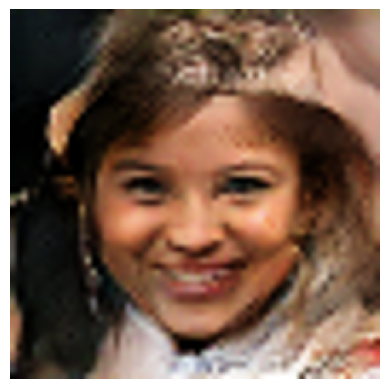

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

generator = tf.keras.models.load_model("generator_50k_epoch_150.keras")
latent_dim = 100
noise = tf.random.normal([1, 1, 1, latent_dim])
generated_image = generator(noise, training=False)
generated_image = (generated_image + 1) / 2.0
generated_image = tf.clip_by_value(generated_image, 0, 1)

upscaled_image = tf.image.resize(generated_image, [260, 260], method='bicubic')


plt.imsave("output_sample.png", tf.clip_by_value(upscaled_image[0], 0, 1).numpy())

plt.imshow(upscaled_image[0].numpy())
plt.axis("off")
plt.show()

